In [105]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [106]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [108]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [109]:
from sklearn.neural_network import MLPClassifier
digit_mlpClassifier = MLPClassifier(
    hidden_layer_sizes=[50],
    solver='sgd',
    max_iter=100,
    verbose=10,
    random_state=1,
    learning_rate_init=0.1,
    alpha=0.0001
).fit(X_train, y_train)

Iteration 1, loss = 0.31082699
Iteration 2, loss = 0.19793485
Iteration 3, loss = 0.23154453
Iteration 4, loss = 0.20712224
Iteration 5, loss = 0.19454863
Iteration 6, loss = 0.15586130
Iteration 7, loss = 0.12863538
Iteration 8, loss = 0.11015649
Iteration 9, loss = 0.14696815
Iteration 10, loss = 0.11989608
Iteration 11, loss = 0.12569941
Iteration 12, loss = 0.13863052
Iteration 13, loss = 0.12369351
Iteration 14, loss = 0.13805650
Iteration 15, loss = 0.12377351
Iteration 16, loss = 0.11882979
Iteration 17, loss = 0.13416095
Iteration 18, loss = 0.14761757
Iteration 19, loss = 0.18909803
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


In [110]:
print(f"Training set accuracy: {digit_mlpClassifier.score(X_train, y_train)}")
print(f"Test Set accuracy: {digit_mlpClassifier.score(X_test, y_test)}")

Training set accuracy: 0.9774857142857143
Test Set accuracy: 0.9489142857142857


In [111]:
import pickle
pickle.dump(digit_mlpClassifier, open("models/digitClassifier", "wb"))

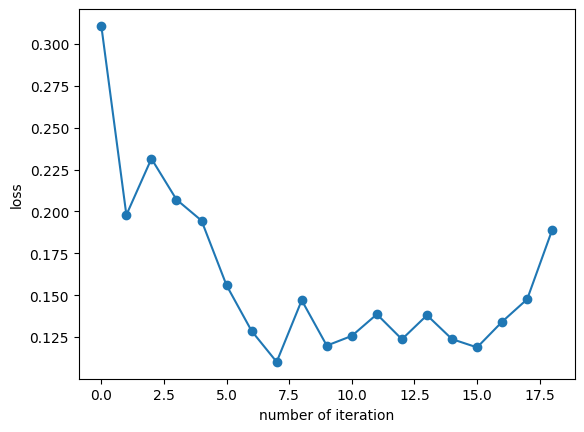

In [112]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1)
axes.plot(digit_mlpClassifier.loss_curve_, 'o-')
axes.set_xlabel("number of iteration")
axes.set_ylabel("loss")
plt.show()


## Activity: Using ANNs to predict handwritten digits

In [113]:
import cv2
import pickle
digit_classifier = pickle.load(open("models/digitClassifier", 'rb'))
raw_image = cv2.imread("images/number5.jpg")

In [114]:
raw_image = cv2.resize(raw_image, (28,28), interpolation=cv2.INTER_AREA)
raw_image = cv2.cvtColor(raw_image, cv2.COLOR_BGR2GRAY)

In [115]:
cv2.imshow("resized", raw_image)
cv2.waitKey(0)

-1

In [116]:
raw_image = raw_image.flatten().reshape(1,784)

In [117]:
import numpy as np
raw_image = np.interp(raw_image, (raw_image.min(), raw_image.max()), (-1,1))

In [118]:
prediction = digit_classifier.predict(raw_image)
print(prediction)

['8']
